In [1]:
# imports
import os, sys

# third party imports
import numpy as np
import tensorflow as tf
assert tf.__version__.startswith('2.'), 'This tutorial assumes Tensorflow 2.0+'
# local imports
import voxelmorph as vxm
import neurite as ne

C:\Users\user\anaconda3\envs\nn\lib\site-packages\h5py\__init__.py:36: UserWarning: h5py is running against HDF5 1.12.2 when it was built against 1.12.1, this may cause problems
  _warn(("h5py is running against HDF5 {0} when it was built against {1}, "



backend:pytorch22
tf


In [2]:
#訓練データの読み込み
#検証データの読み込み
npz = np.load('tutorial_data.npz')
x_train = npz['train']
x_val = npz['validate']
# the 208 volumes are of size 160x192
vol_shape = x_train.shape[1:]
print('train shape:', x_train.shape)

train shape: (208, 192, 160)


In [3]:
# configure unet input shape (concatenation of moving and fixed images)
ndim = 2
unet_input_features = 2
inshape = (*x_train.shape[1:], unet_input_features)

# configure unet features 
nb_features = [
    [32, 32, 32, 32],         # encoder features
    [32, 32, 32, 32, 32, 16]  # decoder features
]

# build model
unet = vxm.networks.Unet(inshape=inshape, nb_features=nb_features)

In [4]:
# transform the results into a flow field.
disp_tensor = tf.keras.layers.Conv2D(ndim, kernel_size=3, padding='same', name='disp')(unet.output)

# check tensor shape
print('displacement tensor:', disp_tensor.shape)

# using keras, we can easily form new models via tensor pointers
def_model = tf.keras.models.Model(unet.inputs, disp_tensor)
# build transformer layer
spatial_transformer = vxm.layers.SpatialTransformer(name='transformer')

# extract the first frame (i.e. the "moving" image) from unet input tensor
moving_image = tf.expand_dims(unet.input[..., 0], axis=-1)

# warp the moving image with the transformer
moved_image_tensor = spatial_transformer([moving_image, disp_tensor])
outputs = [moved_image_tensor, disp_tensor]
vxm_model = tf.keras.models.Model(inputs=unet.inputs, outputs=outputs)
# build model using VxmDense
inshape = x_train.shape[1:]
vxm_model = vxm.networks.VxmDense(inshape, nb_features, int_steps=0)

displacement tensor: (None, 192, 160, 2)



In [5]:
# voxelmorph has a variety of custom loss classes
losses = [vxm.losses.MSE().loss, vxm.losses.Grad('l2').loss]

# usually, we have to balance the two losses by a hyper-parameter
lambda_param = 0.05
loss_weights = [1, lambda_param]
vxm_model.compile(optimizer='Adam', loss=losses, loss_weights=loss_weights)

In [6]:
def vxm_data_generator(x_data, batch_size=32):
    """
    Generator that takes in data of size [N, H, W], and yields data for
    our custom vxm model. Note that we need to provide numpy data for each
    input, and each output.

    inputs:  moving [bs, H, W, 1], fixed image [bs, H, W, 1]
    outputs: moved image [bs, H, W, 1], zero-gradient [bs, H, W, 2]
    """

    # preliminary sizing
    vol_shape = x_data.shape[1:] # extract data shape
    ndims = len(vol_shape)
    
    # prepare a zero array the size of the deformation
    # we'll explain this below
    zero_phi = np.zeros([batch_size, *vol_shape, ndims])
    
    while True:
        # prepare inputs:
        # images need to be of the size [batch_size, H, W, 1]
        idx1 = np.random.randint(0, x_data.shape[0], size=batch_size)
        moving_images = x_data[idx1, ..., np.newaxis]
        idx2 = np.random.randint(0, x_data.shape[0], size=batch_size)
        fixed_images = x_data[idx2, ..., np.newaxis]
        inputs = [moving_images, fixed_images]
        
        # prepare outputs (the 'true' moved image):
        # of course, we don't have this, but we know we want to compare 
        # the resulting moved image with the fixed image. 
        # we also wish to penalize the deformation field. 
        outputs = [fixed_images, zero_phi]
        
        yield (inputs, outputs)

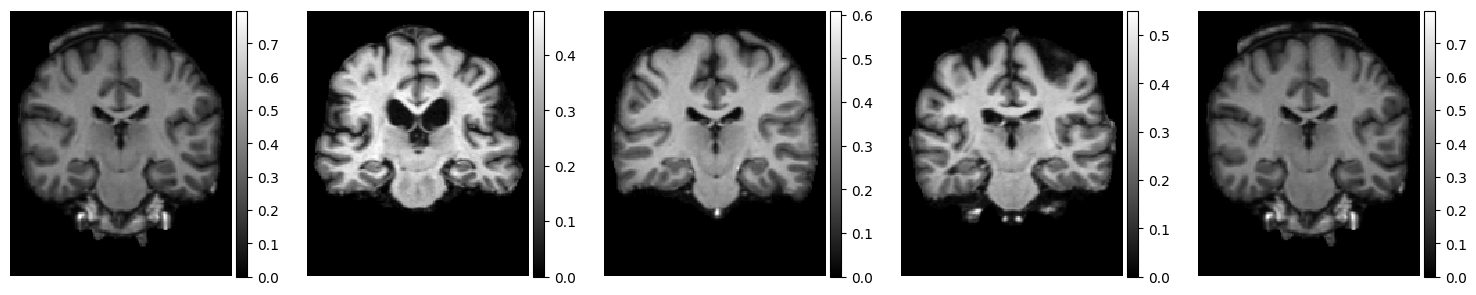

In [7]:
# extract some brains
nb_vis = 5
idx = np.random.randint(0, x_train.shape[0], [5,])
example_digits = [f for f in x_train[idx, ...]]

# visualize
ne.plot.slices(example_digits, cmaps=['gray'], do_colorbars=True);

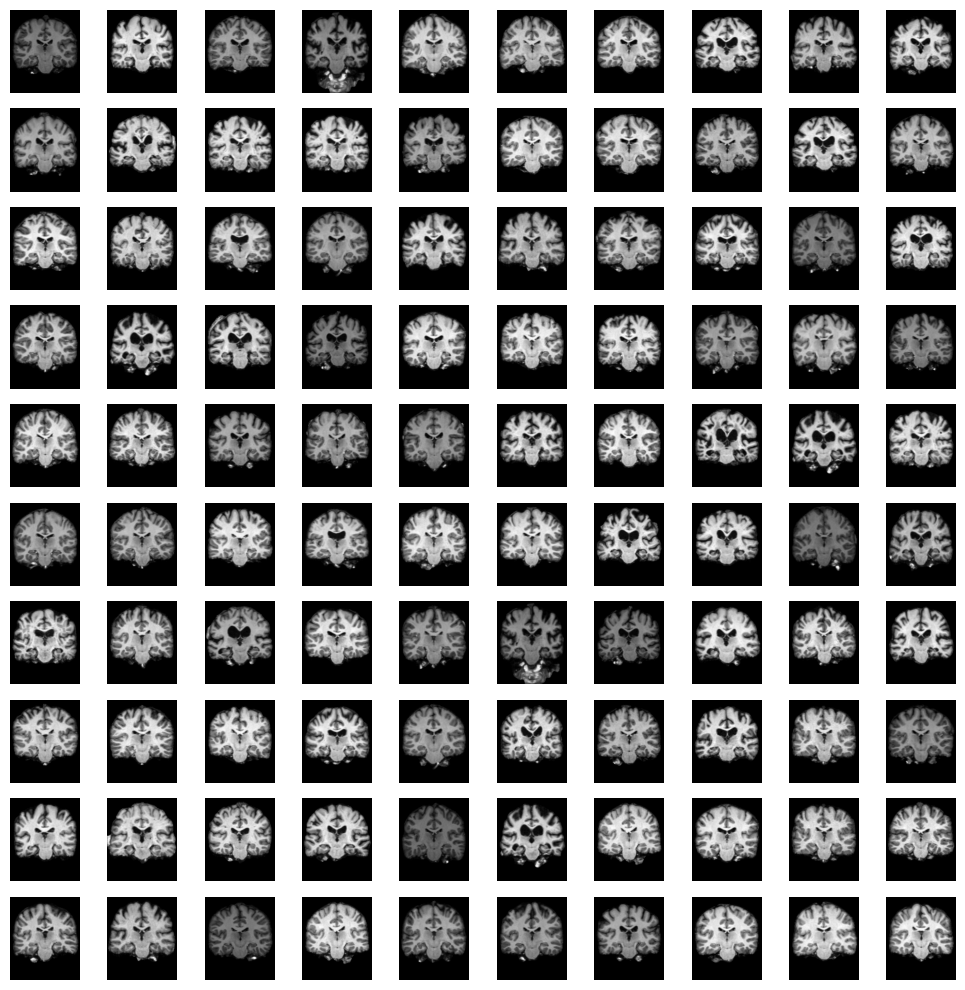

In [8]:
import matplotlib.pyplot as plt

nb_vis = 100  # 表示する画像の数を変更
idx = np.random.randint(0, x_train.shape[0], [nb_vis,])
example_digits = [f for f in x_train[idx, ...]]

# 10x10のグリッドを作成して画像を配置する
fig, axes = plt.subplots(10, 10, figsize=(10, 10))  # 10x10のグリッド

for i in range(10):
    for j in range(10):
        axes[i, j].imshow(example_digits[i * 10 + j], cmap='gray')
        axes[i, j].axis('off')

plt.tight_layout()
plt.show()

In [9]:
# unet
vxm_model = vxm.networks.VxmDense(vol_shape, nb_features, int_steps=0)

# losses and loss weights
losses = ['mse', vxm.losses.Grad('l2').loss]
loss_weights = [1, 0.01]
vxm_model.compile(optimizer=tf.keras.optimizers.Adam(lr=1e-4), loss=losses, loss_weights=loss_weights)

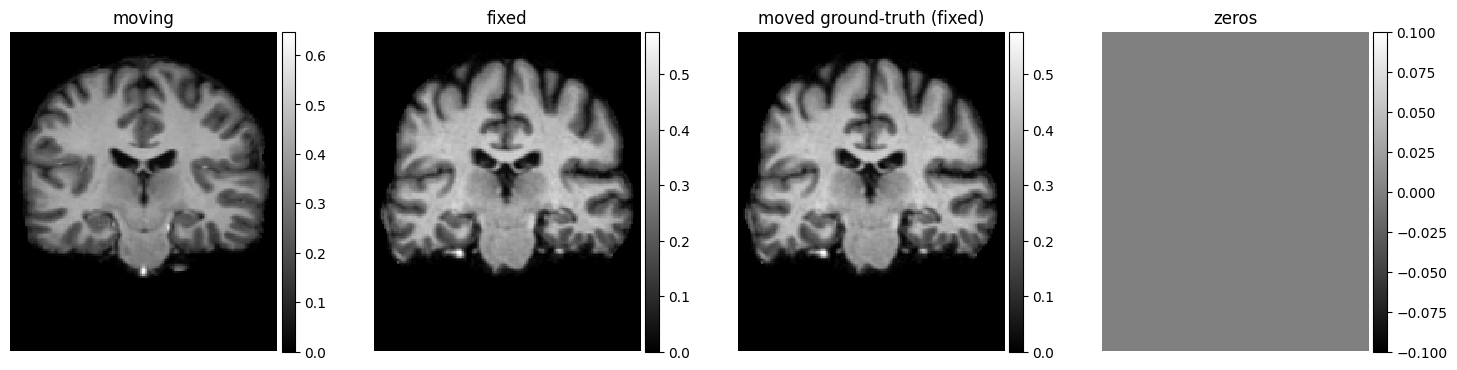

In [10]:
# let's test it
train_generator = vxm_data_generator(x_train, batch_size=8)
in_sample, out_sample = next(train_generator)

# visualize
images = [img[0, :, :, 0] for img in in_sample + out_sample]
titles = ['moving', 'fixed', 'moved ground-truth (fixed)', 'zeros']
ne.plot.slices(images, titles=titles, cmaps=['gray'], do_colorbars=True);

In [11]:
hist = vxm_model.fit_generator(train_generator, epochs=10, steps_per_epoch=10, verbose=2);

Epoch 1/10


C:\Users\user\AppData\Local\Temp\ipykernel_11152\2013185830.py:1: UserWarning: `Model.fit_generator` is deprecated and will be removed in a future version. Please use `Model.fit`, which supports generators.
  hist = vxm_model.fit_generator(train_generator, epochs=10, steps_per_epoch=10, verbose=2);


10/10 - 6s - loss: 0.0071 - vxm_dense_transformer_loss: 0.0071 - vxm_dense_flow_loss: 7.9095e-05 - 6s/epoch - 612ms/step
Epoch 2/10
10/10 - 3s - loss: 0.0068 - vxm_dense_transformer_loss: 0.0068 - vxm_dense_flow_loss: 2.4129e-04 - 3s/epoch - 269ms/step
Epoch 3/10
10/10 - 3s - loss: 0.0063 - vxm_dense_transformer_loss: 0.0063 - vxm_dense_flow_loss: 0.0012 - 3s/epoch - 291ms/step
Epoch 4/10
10/10 - 3s - loss: 0.0054 - vxm_dense_transformer_loss: 0.0053 - vxm_dense_flow_loss: 0.0145 - 3s/epoch - 287ms/step
Epoch 5/10
10/10 - 3s - loss: 0.0048 - vxm_dense_transformer_loss: 0.0043 - vxm_dense_flow_loss: 0.0474 - 3s/epoch - 299ms/step
Epoch 6/10
10/10 - 3s - loss: 0.0040 - vxm_dense_transformer_loss: 0.0034 - vxm_dense_flow_loss: 0.0602 - 3s/epoch - 287ms/step
Epoch 7/10
10/10 - 3s - loss: 0.0036 - vxm_dense_transformer_loss: 0.0031 - vxm_dense_flow_loss: 0.0568 - 3s/epoch - 302ms/step
Epoch 8/10
10/10 - 3s - loss: 0.0041 - vxm_dense_transformer_loss: 0.0034 - vxm_dense_flow_loss: 0.0641 - 3

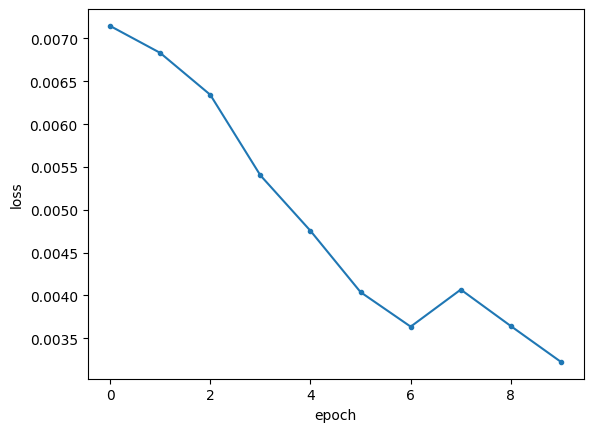

In [12]:
# as before, let's visualize what happened
import matplotlib.pyplot as plt

def plot_history(hist, loss_name='loss'):
    # Simple function to plot training history.
    plt.figure()
    plt.plot(hist.epoch, hist.history[loss_name], '.-')
    plt.ylabel('loss')
    plt.xlabel('epoch')
    plt.show()
    
plot_history(hist)

1/1 [==============================] - 0s 346ms/step


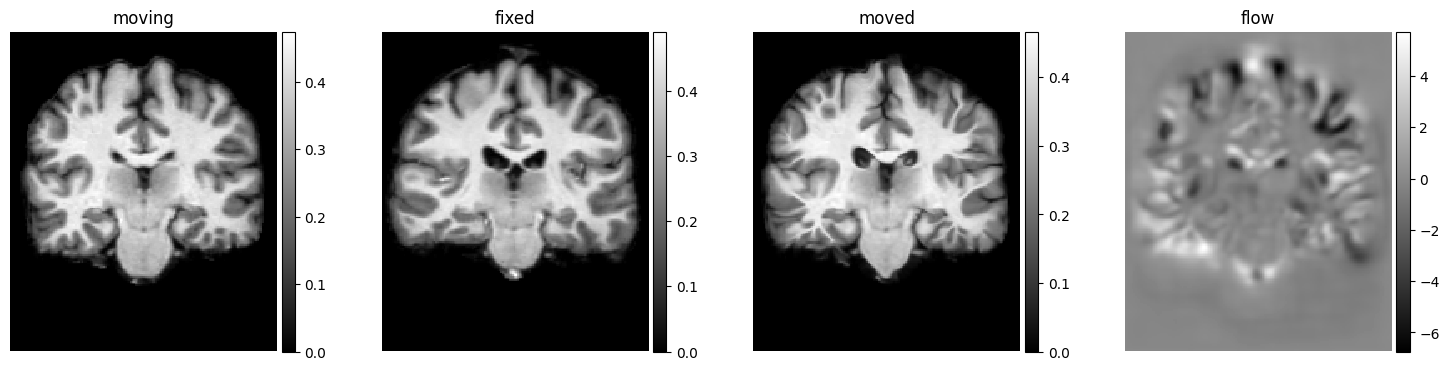

In [14]:
# create the validation data generator
val_generator = vxm_data_generator(x_val, batch_size = 1)
val_input, _ = next(val_generator)
# prediction
val_pred = vxm_model.predict(val_input)
# visualize registration
images = [img[0, :, :, 0] for img in val_input + val_pred] 
titles = ['moving', 'fixed', 'moved', 'flow']
ne.plot.slices(images, titles=titles, cmaps=['gray'], do_colorbars=True);

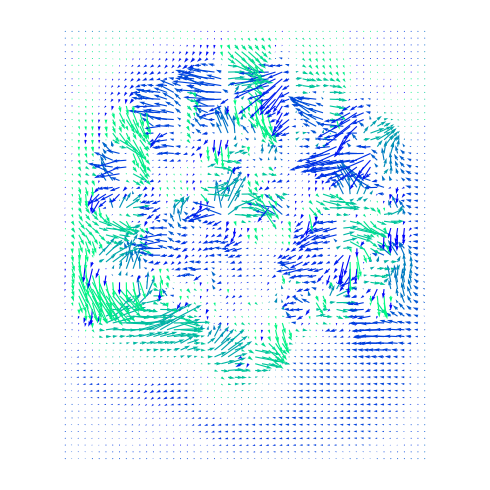

In [15]:
# visualize flow
flow = val_pred[1].squeeze()[::3,::3]
ne.plot.flow([flow], width=5);

In [16]:
# our data will be of shape 160 x 192 x 224
vol_shape = (224, 224, 224)
nb_features = [
    [16, 32, 32, 32],
    [32, 32, 32, 32, 32, 16, 16]
]

In [17]:
# build vxm network
vxm_model = vxm.networks.VxmDense(vol_shape, nb_features, int_steps=0);
# losses and loss weights
losses = ['mse', vxm.losses.Grad('l2').loss]
loss_weights = [1, 0.01]
vxm_model.compile(optimizer=tf.keras.optimizers.Adam(lr=1e-4), loss=losses, loss_weights=loss_weights)

In [18]:
x_train = np.load('output_small_data.npz')['train']
print('train shape:', x_train.shape)

train shape: (4, 224, 224, 224)


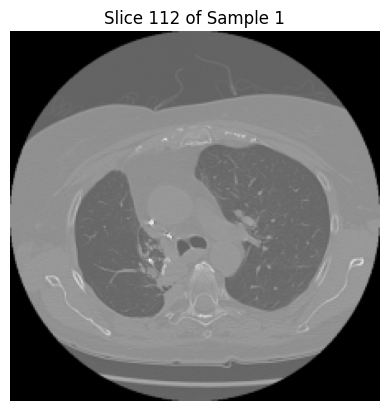

In [19]:
import matplotlib.pyplot as plt

# 4番目のサンプルをプロット
sample_index = 1  # 0から数えて4番目のサンプルを表示
volume_data = x_train[sample_index]  # 4番目のサンプルを取得

# ボリュームデータのスライスをプロット
slice_index = 112  # スライスのインデックスを選択
plt.imshow(volume_data[:, :, slice_index], cmap='gray')
plt.axis('off')
plt.title(f'Slice {slice_index} of Sample {sample_index}')
plt.show()

In [ ]:
train_generator = vxm_data_generator(x_train, batch_size=8)

In [ ]:
hist = vxm_model.fit_generator(train_generator, epochs=10, steps_per_epoch=100, verbose=2);

In [ ]:
# as before, let's visualize what happened
import matplotlib.pyplot as plt

def plot_history(hist, loss_name='loss'):
    # Simple function to plot training history.
    plt.figure()
    plt.plot(hist.epoch, hist.history[loss_name], '.-')
    plt.ylabel('loss')
    plt.xlabel('epoch')
    plt.show()
    
plot_history(hist)